# HOTEL BOOKING DEMAND ANALYSIS PROJECT

In [1]:
print("Hotel Booking Demand Analysis")
print("Dataset: hotel_bookings.csv")
print("Objective: Analyze hotel booking patterns and predict booking cancellation.")

Hotel Booking Demand Analysis
Dataset: hotel_bookings.csv
Objective: Analyze hotel booking patterns and predict booking cancellation.


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv("hotel_bookings.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [4]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [5]:
print("Dataset Shape:", df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset Shape: (119390, 32)
Rows: 119390
Columns: 32


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [7]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [8]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

company     112593
agent        16340
country        488
children         4
dtype: int64

In [9]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage[missing_percentage > 0].sort_values(ascending=False)

company     94.306893
agent       13.686238
country      0.408744
children     0.003350
dtype: float64

In [10]:
df['children'] = df['children'].fillna(
    df['children'].median()
)

df['country'] = df['country'].fillna(
    df['country'].mode()[0]
)

df['agent'] = df['agent'].fillna(0)

df['company'] = df['company'].fillna(0)

print("Missing values handled successfully!")

Missing values handled successfully!


In [11]:
df.isnull().sum().sum()

np.int64(0)

In [12]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 32013


In [13]:
df.drop_duplicates(inplace=True)

print("Duplicates removed successfully!")
print("New Shape:", df.shape)

Duplicates removed successfully!
New Shape: (87377, 32)


In [14]:
df.dtypes

hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                          str
agent                             

### Total Guests Feature

In [15]:
df['total_guests'] = (
    df['adults'] +
    df['children'] +
    df['babies']
)

df[['adults', 'children', 'babies', 'total_guests']].head()

,adults,children,babies,total_guests
0,2,0.0,0,2.0
1,2,0.0,0,2.0
2,1,0.0,0,1.0
3,1,0.0,0,1.0
4,2,0.0,0,2.0


### Total Stay Nights

In [16]:
df['total_nights'] = (
    df['stays_in_weekend_nights'] +
    df['stays_in_week_nights']
)

df[['stays_in_weekend_nights',
    'stays_in_week_nights',
    'total_nights']].head()


,stays_in_weekend_nights,stays_in_week_nights,total_nights
0,0,0,0
1,0,0,0
2,0,1,1
3,0,1,1
4,0,2,2


### Total Cost Feature

In [17]:
df['total_cost'] = (
    df['adr'] *
    df['total_nights']
)

df[['adr', 'total_nights', 'total_cost']].head()

,adr,total_nights,total_cost
0,0.0,0,0.0
1,0.0,0,0.0
2,75.0,1,75.0
3,75.0,1,75.0
4,98.0,2,196.0


In [18]:
df['meal'].value_counts()

meal
BB           67962
SC            9481
HB            9084
Undefined      490
FB             360
Name: count, dtype: int64

In [19]:
df['reservation_status'].value_counts()

reservation_status
Check-Out    63353
Canceled     23010
No-Show       1014
Name: count, dtype: int64

### Booking Month Order

In [20]:
months_order = [
    'January', 'February', 'March',
    'April', 'May', 'June',
    'July', 'August', 'September',
    'October', 'November', 'December'
]

df['arrival_date_month'] = pd.Categorical(
    df['arrival_date_month'],
    categories=months_order,
    ordered=True
)

print("Month ordering completed!")

Month ordering completed!


In [21]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_guests,total_nights,total_cost
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0,Transient,0.0,0,0,Check-Out,2015-07-01,2.0,0,0.0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0,Transient,0.0,0,0,Check-Out,2015-07-01,2.0,0,0.0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,Transient,75.0,0,0,Check-Out,2015-07-02,1.0,1,75.0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,Transient,75.0,0,0,Check-Out,2015-07-02,1.0,1,75.0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,Transient,98.0,0,1,Check-Out,2015-07-03,2.0,2,196.0


In [22]:
df.to_csv(
    "hotel_bookings_cleaned.csv",
    index=False
)

print("Cleaned dataset saved!")

Cleaned dataset saved!


## EXPLORATORY DATA ANALYSIS (EDA)

In [23]:
print("Dataset Shape:", df.shape)
print("Columns:", df.columns.tolist())

Dataset Shape: (87377, 35)
Columns: ['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date', 'total_guests', 'total_nights', 'total_cost']


## Booking Cancellation Distribution
Business Question:

How many bookings were cancelled?

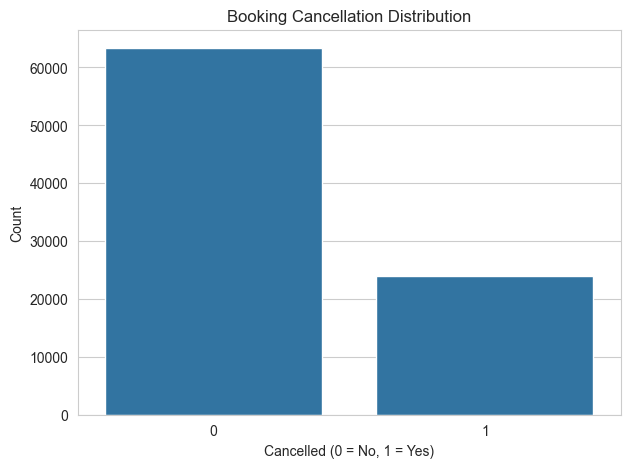

In [24]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='is_canceled',
    data=df
)

plt.title("Booking Cancellation Distribution")
plt.xlabel("Cancelled (0 = No, 1 = Yes)")
plt.ylabel("Count")

plt.show()

## Cancellation Percentage

In [25]:
cancel_rate = df['is_canceled'].value_counts(normalize=True) * 100

print(cancel_rate)

is_canceled
0    72.50535
1    27.49465
Name: proportion, dtype: float64


## Hotel Type Distribution
Business Question:

Which hotel receives more bookings?

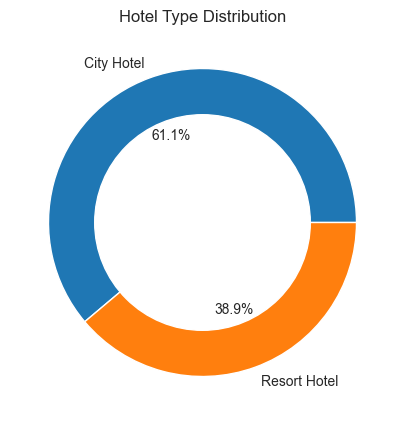

In [26]:
hotel_counts = df['hotel'].value_counts()

plt.figure(figsize=(7,5))

plt.pie(
    hotel_counts,
    labels=hotel_counts.index,
    autopct='%1.1f%%'
)

# buat lubang tengah
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Hotel Type Distribution")

plt.show()

## Hotel Type vs Cancellation
Business Question:

Which hotel type has more cancellations?

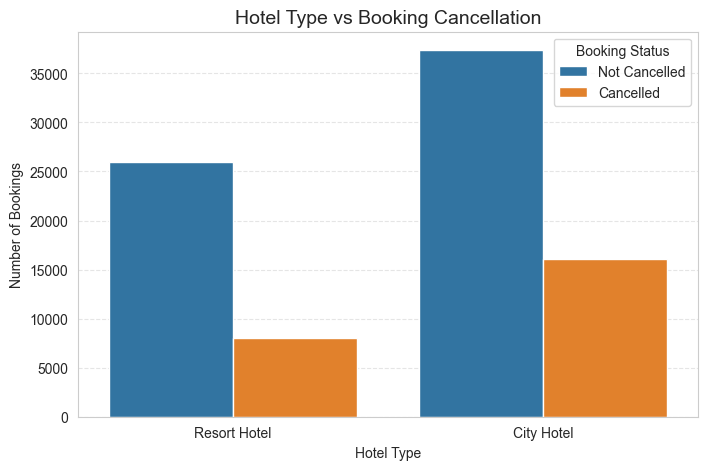

In [27]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='hotel',
    hue='is_canceled',
    data=df
)

plt.title("Hotel Type vs Booking Cancellation", fontsize=14)
plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")

plt.legend(
    title="Booking Status",
    labels=["Not Cancelled", "Cancelled"]
)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

## Monthly Booking Trend
Business Question:

Which month receives the highest bookings?

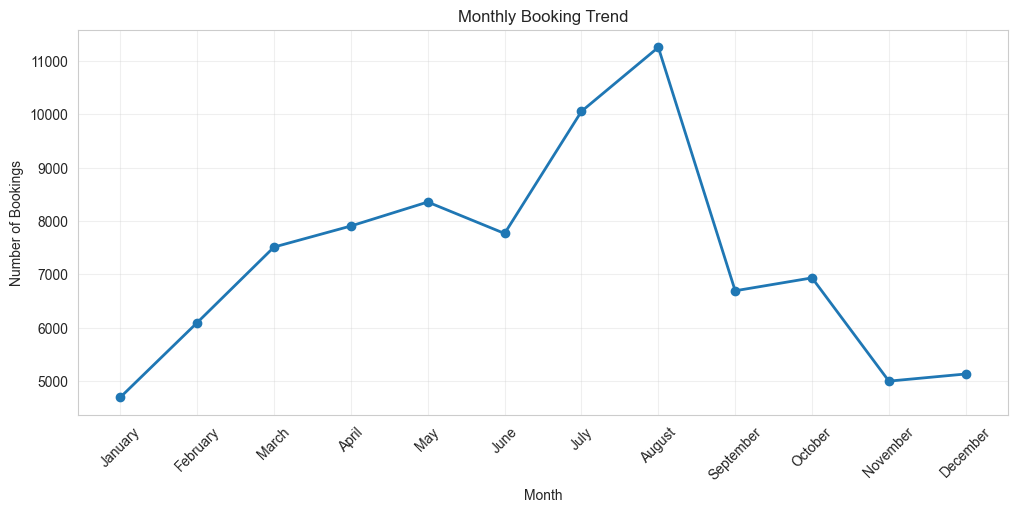

In [28]:
monthly_booking = df['arrival_date_month'].value_counts()

month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

monthly_booking = monthly_booking.reindex(month_order)

plt.figure(figsize=(12,5))

plt.plot(
    monthly_booking.index,
    monthly_booking.values,
    marker='o',
    linewidth=2
)

plt.title("Monthly Booking Trend")
plt.xlabel("Month")
plt.ylabel("Number of Bookings")

plt.grid(alpha=0.3)
plt.xticks(rotation=45)

plt.show()

## Lead Time Distribution
Business Question:

How early do customers book?

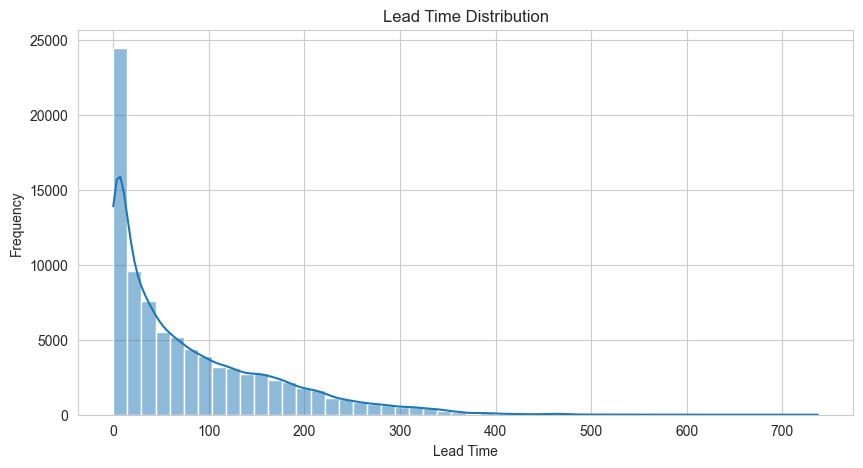

In [29]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['lead_time'],
    bins=50,
    kde=True
)

plt.title("Lead Time Distribution")
plt.xlabel("Lead Time")
plt.ylabel("Frequency")

plt.show()

## Average Daily Rate (ADR)
Business Question:

How are hotel prices distributed?

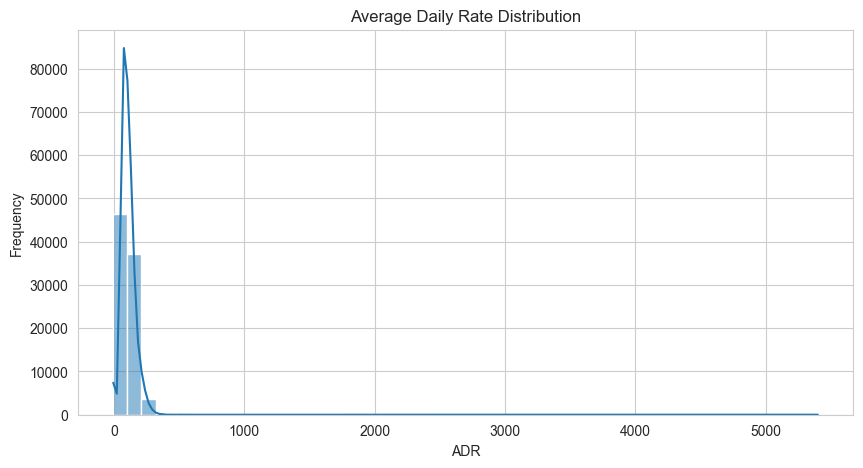

In [30]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['adr'],
    bins=50,
    kde=True
)

plt.title("Average Daily Rate Distribution")
plt.xlabel("ADR")
plt.ylabel("Frequency")

plt.show()

## Top 10 Countries by Booking
Business Question:

Which countries contribute the most bookings?

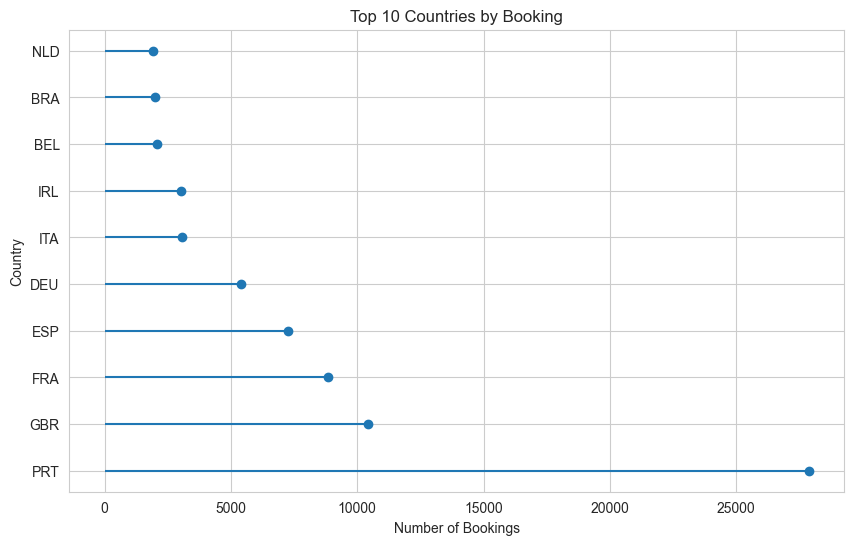

In [31]:
top_countries = (
    df['country']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

plt.hlines(
    y=top_countries.index,
    xmin=0,
    xmax=top_countries.values
)

plt.plot(
    top_countries.values,
    top_countries.index,
    "o"
)

plt.title("Top 10 Countries by Booking")
plt.xlabel("Number of Bookings")
plt.ylabel("Country")

plt.show()

## Market Segment Distribution
Business Question:

Which customer market segment dominates?

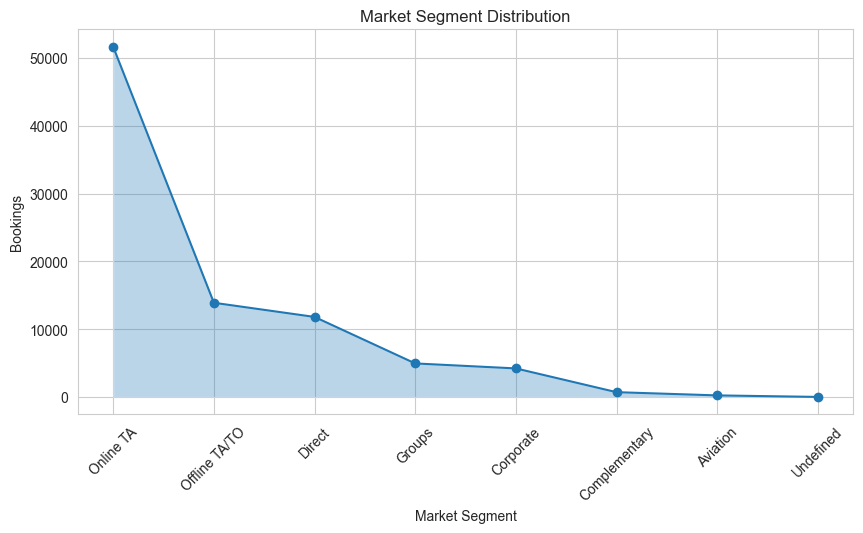

In [32]:
market_counts = df['market_segment'].value_counts()

plt.figure(figsize=(10,5))

plt.fill_between(
    market_counts.index,
    market_counts.values,
    alpha=0.3
)

plt.plot(
    market_counts.index,
    market_counts.values,
    marker='o'
)

plt.title("Market Segment Distribution")
plt.xlabel("Market Segment")
plt.ylabel("Bookings")

plt.xticks(rotation=45)

plt.show()

## Deposit Type Distribution
Business Question:

Which deposit type is most common?

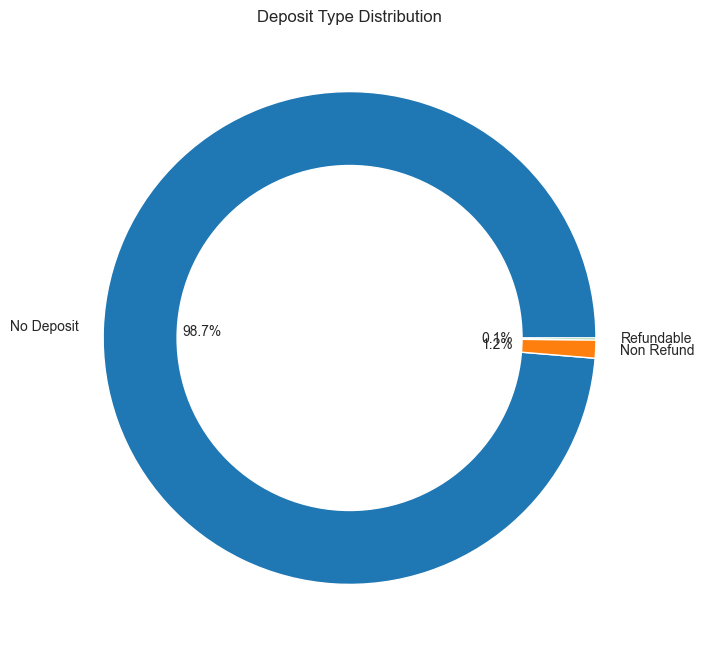

In [33]:
deposit_counts = df['deposit_type'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    deposit_counts,
    labels=deposit_counts.index,
    autopct='%1.1f%%'
)

# buat lubang tengah
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Deposit Type Distribution")

plt.show()

## Customer Type Distribution
Business Question:

What type of customers book hotels?

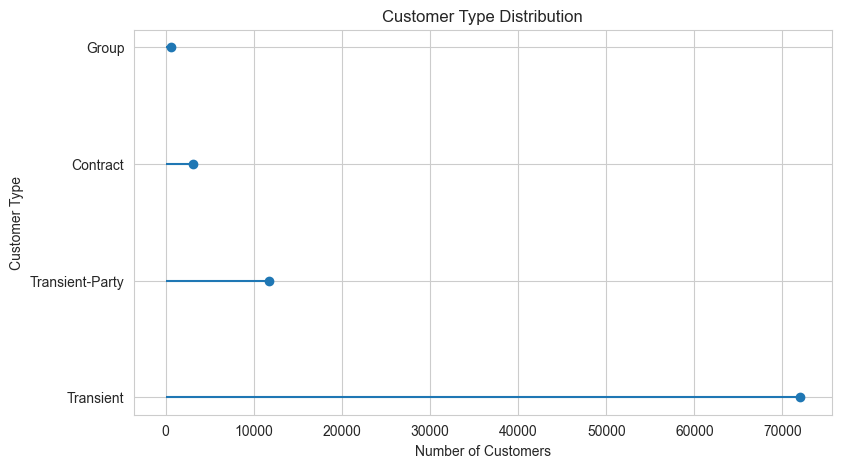

In [34]:
customer_counts = df['customer_type'].value_counts()

plt.figure(figsize=(9,5))

plt.hlines(
    y=customer_counts.index,
    xmin=0,
    xmax=customer_counts.values
)

plt.plot(
    customer_counts.values,
    customer_counts.index,
    "o"
)

plt.title("Customer Type Distribution")
plt.xlabel("Number of Customers")
plt.ylabel("Customer Type")

plt.show()

## Average ADR by Hotel Type
Business Question:

Which hotel generates higher room rates?

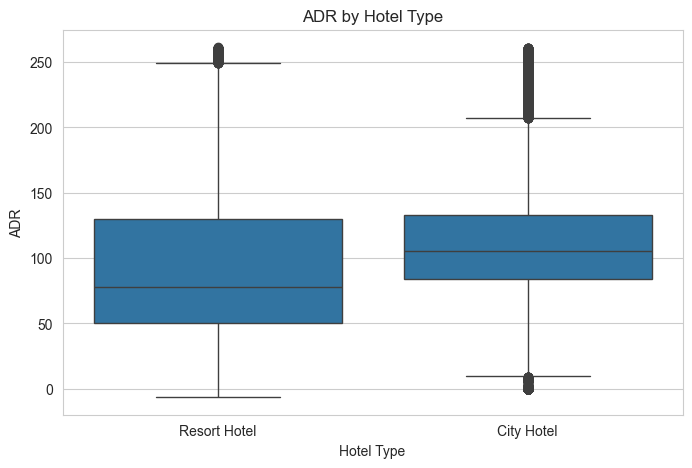

In [35]:
q99 = df['adr'].quantile(0.99)

df_filtered = df[df['adr'] <= q99]

plt.figure(figsize=(8,5))

sns.boxplot(
    x='hotel',
    y='adr',
    data=df_filtered
)

plt.title("ADR by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("ADR")

plt.show()

## Stay Duration Distribution
Business Question:

How long do guests stay?

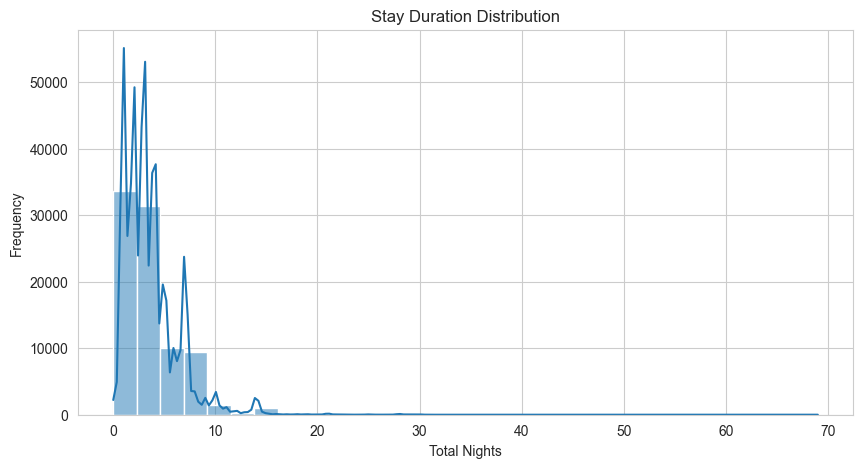

In [36]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['total_nights'],
    bins=30,
    kde=True
)

plt.title("Stay Duration Distribution")
plt.xlabel("Total Nights")
plt.ylabel("Frequency")

plt.show()

## Family vs Non-Family Guests
Business Question:

Do families book hotels more often?

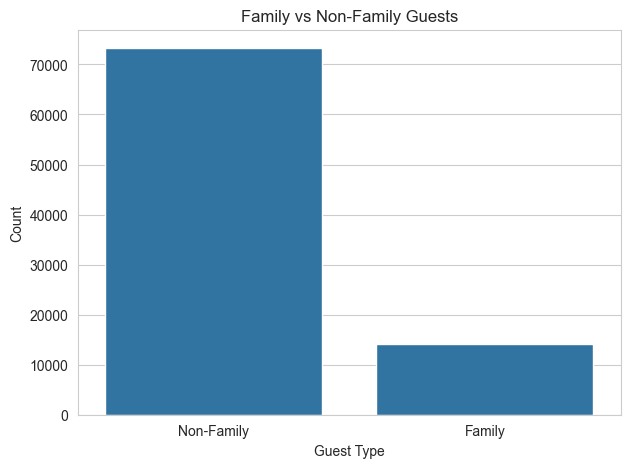

In [37]:
df['is_family'] = np.where(
    df['total_guests'] > 2,
    'Family',
    'Non-Family'
)

plt.figure(figsize=(7,5))

sns.countplot(
    x='is_family',
    data=df
)

plt.title("Family vs Non-Family Guests")
plt.xlabel("Guest Type")
plt.ylabel("Count")

plt.show()

## Cancellation by Deposit Type
Business Question:

Does deposit type affect cancellation?

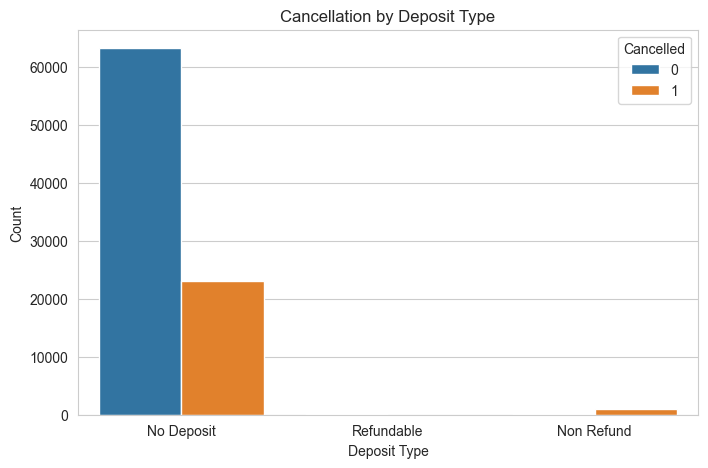

In [38]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='deposit_type',
    hue='is_canceled',
    data=df
)

plt.title("Cancellation by Deposit Type")
plt.xlabel("Deposit Type")
plt.ylabel("Count")

plt.legend(title="Cancelled")

plt.show()

## Repeat Guests Analysis
Business Question:

Do repeat guests return often?

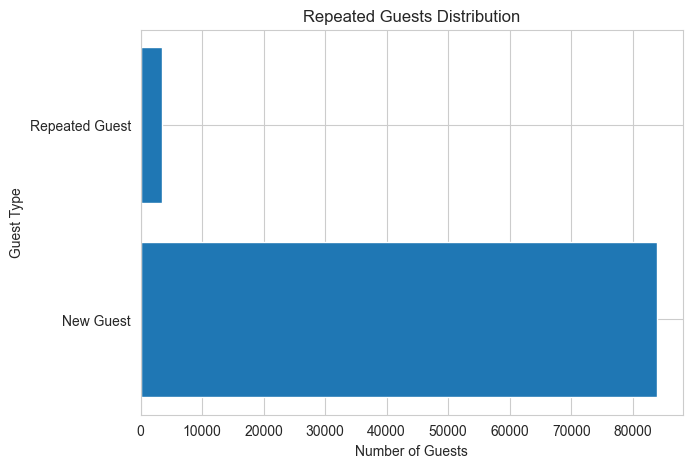

In [39]:
repeat_counts = df['is_repeated_guest'].value_counts()

plt.figure(figsize=(7,5))

plt.barh(
    ['New Guest', 'Repeated Guest'],
    repeat_counts.values
)

plt.title("Repeated Guests Distribution")
plt.xlabel("Number of Guests")
plt.ylabel("Guest Type")

plt.show()

## Booking Source Distribution
Business Question:

Where do most bookings come from?

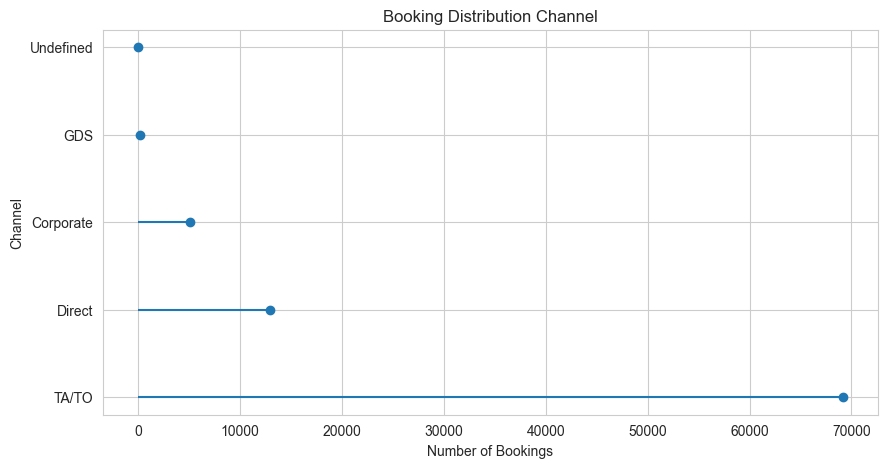

In [40]:
channel_counts = df['distribution_channel'].value_counts()

plt.figure(figsize=(10,5))

plt.hlines(
    y=channel_counts.index,
    xmin=0,
    xmax=channel_counts.values
)

plt.plot(
    channel_counts.values,
    channel_counts.index,
    "o"
)

plt.title("Booking Distribution Channel")
plt.xlabel("Number of Bookings")
plt.ylabel("Channel")

plt.show()

## BUSINESS INSIGHTS SECTION

### Cancellation Rate by Hotel Type

In [41]:
hotel_cancel = (
    df.groupby('hotel')['is_canceled']
    .mean()
    * 100
)

print(hotel_cancel)

hotel
City Hotel      30.038557
Resort Hotel    23.491119
Name: is_canceled, dtype: float64


### Highest Revenue Potential Month

In [42]:
monthly_revenue = (
    df.groupby('arrival_date_month')['total_cost']
    .sum()
    .sort_values(ascending=False)
)

monthly_revenue.head(10)

arrival_date_month
August       7240652.99
July         5861872.59
June         3496345.05
May          3123058.22
April        2786805.89
September    2689186.19
March        2048381.33
October      2032533.25
February     1473273.20
December     1407060.17
Name: total_cost, dtype: float64

### Average Stay Duration by Hotel

In [43]:
avg_stay = (
    df.groupby('hotel')['total_nights']
    .mean()
)

print(avg_stay)

hotel
City Hotel      3.146609
Resort Hotel    4.393414
Name: total_nights, dtype: float64


### Top Market Segments by Revenue

In [44]:
segment_revenue = (
    df.groupby('market_segment')['total_cost']
    .sum()
    .sort_values(ascending=False)
)

segment_revenue.head(10)

market_segment
Online TA        22266312.72
Offline TA/TO     5416418.59
Direct            4855406.52
Groups            1237708.96
Corporate          593842.08
Aviation            83033.36
Complementary        5074.52
Undefined              48.00
Name: total_cost, dtype: float64

### Summary of EDA Insights

In [45]:
print("""
EDA SUMMARY

1. Booking cancellation patterns identified.
2. Monthly booking trends discovered.
3. Customer booking behavior analyzed.
4. Hotel pricing patterns explored.
5. Market segments contributing revenue identified.
6. Family and repeated guest patterns explored.
7. Booking sources analyzed.
8. Revenue opportunity months discovered.
""")


EDA SUMMARY

1. Booking cancellation patterns identified.
2. Monthly booking trends discovered.
3. Customer booking behavior analyzed.
4. Hotel pricing patterns explored.
5. Market segments contributing revenue identified.
6. Family and repeated guest patterns explored.
7. Booking sources analyzed.
8. Revenue opportunity months discovered.



# CORRELATION ANALYSIS + DATA PREPARATION FOR MACHINE LEARNING

### Select Numerical Features

In [46]:
numerical_df = df.select_dtypes(
    include=['int64', 'float64']
)

print("Numerical Features:")
print(numerical_df.columns.tolist())

Numerical Features:
['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'total_guests', 'total_nights', 'total_cost']


## Correlation Matrix
### Business Question:

### Which variables are strongly related to booking cancellation?

In [47]:
correlation_matrix = numerical_df.corr()

correlation_matrix

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,total_guests,total_nights,total_cost
is_canceled,1.000000,0.184723,0.088033,0.001380,0.005311,0.060098,0.082858,0.081718,0.067341,-0.020554,...,-0.093681,-0.000900,-0.074712,0.004457,0.127966,-0.184250,-0.120580,0.100164,0.084015,0.139437
lead_time,0.184723,1.000000,0.139163,0.101075,0.009878,0.235062,0.310061,0.140370,0.028601,-0.003630,...,0.076979,0.080453,-0.079112,0.132149,0.023444,-0.086598,0.034198,0.126608,0.318191,0.247543
arrival_date_year,0.088033,0.139163,1.000000,-0.514243,-0.010042,0.005123,0.003655,0.038660,0.041172,-0.023333,...,0.008600,-0.001955,0.021159,-0.027939,0.176205,-0.039800,0.064286,0.050786,0.004629,0.097179
arrival_date_week_number,0.001380,0.101075,-0.514243,1.000000,0.093525,0.026837,0.027716,0.024155,0.013413,0.014251,...,0.011884,0.019557,-0.022437,0.013836,0.098065,0.008909,0.046513,0.028788,0.030618,0.080203
arrival_date_day_of_month,0.005311,0.009878,-0.010042,0.093525,1.000000,-0.017781,-0.028215,-0.001137,0.015835,-0.000390,...,0.006322,0.006179,-0.000420,0.006592,0.022483,0.009180,-0.001690,0.008137,-0.027607,-0.009394
stays_in_weekend_nights,0.060098,0.235062,0.005123,0.026837,-0.017781,1.000000,0.555543,0.088184,0.028526,0.013657,...,0.050275,0.158406,-0.090464,-0.031692,0.038889,-0.042960,0.032380,0.087878,0.786256,0.583276
stays_in_week_nights,0.082858,0.310061,0.003655,0.027716,-0.028215,0.555543,1.000000,0.095464,0.030444,0.015998,...,0.085010,0.190087,-0.065627,0.001896,0.053186,-0.044343,0.037751,0.095056,0.950576,0.704741
adults,0.081718,0.140370,0.038660,0.024155,-0.001137,0.088184,0.095464,1.000000,0.023662,0.016626,...,-0.048113,0.029596,-0.174353,-0.015755,0.248867,0.007751,0.112672,0.804669,0.103871,0.199753
children,0.067341,0.028601,0.041172,0.013413,0.015835,0.028526,0.030444,0.023662,1.000000,0.017417,...,0.031294,0.042033,-0.051034,-0.020424,0.326340,0.036313,0.044584,0.595128,0.033276,0.218982
babies,-0.020554,-0.003630,-0.023333,0.014251,-0.000390,0.013657,0.015998,0.016626,0.017417,1.000000,...,0.081030,0.028951,-0.011421,-0.006841,0.023438,0.030879,0.094825,0.166137,0.016988,0.030726


### Correlation Heatmap

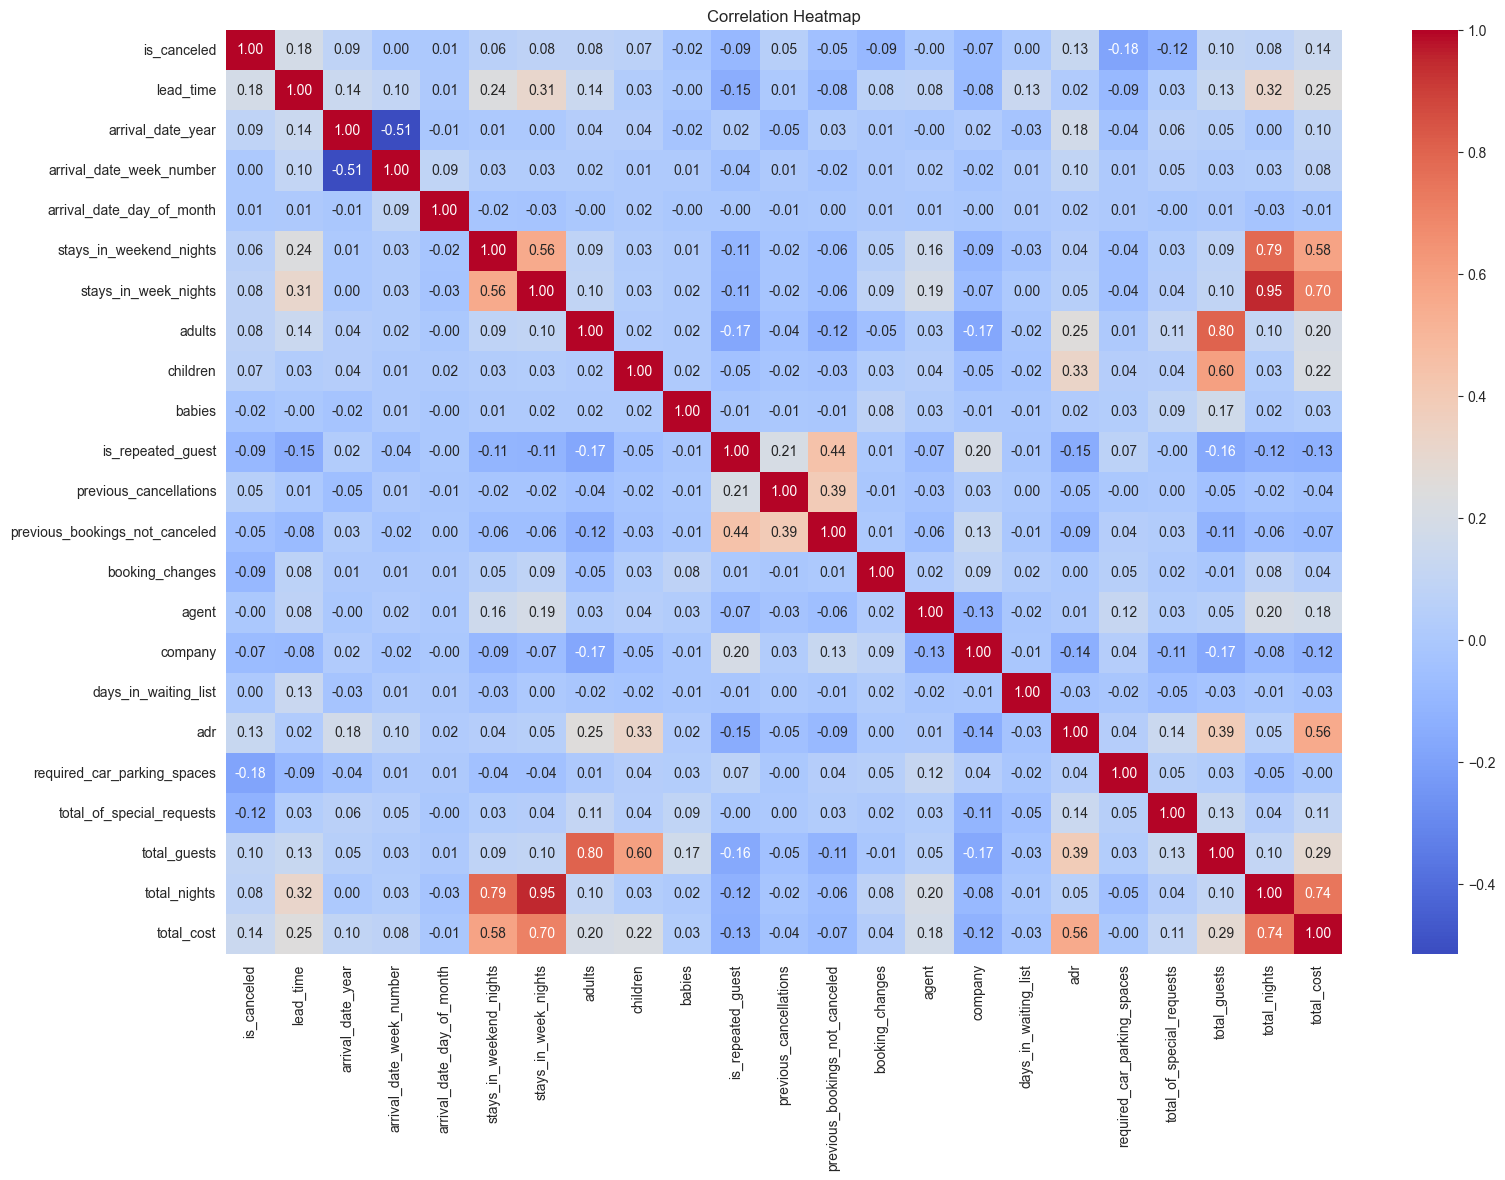

In [48]:
plt.figure(figsize=(18,12))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

### Correlation with Cancellation

In [49]:
cancel_corr = correlation_matrix['is_canceled']\
    .sort_values(ascending=False)

cancel_corr

is_canceled                       1.000000
lead_time                         0.184723
total_cost                        0.139437
adr                               0.127966
total_guests                      0.100164
arrival_date_year                 0.088033
total_nights                      0.084015
stays_in_week_nights              0.082858
adults                            0.081718
children                          0.067341
stays_in_weekend_nights           0.060098
previous_cancellations            0.051462
arrival_date_day_of_month         0.005311
days_in_waiting_list              0.004457
arrival_date_week_number          0.001380
agent                            -0.000900
babies                           -0.020554
previous_bookings_not_canceled   -0.052168
company                          -0.074712
is_repeated_guest                -0.089670
booking_changes                  -0.093681
total_of_special_requests        -0.120580
required_car_parking_spaces      -0.184250
Name: is_ca

### Top Features Affecting Cancellation

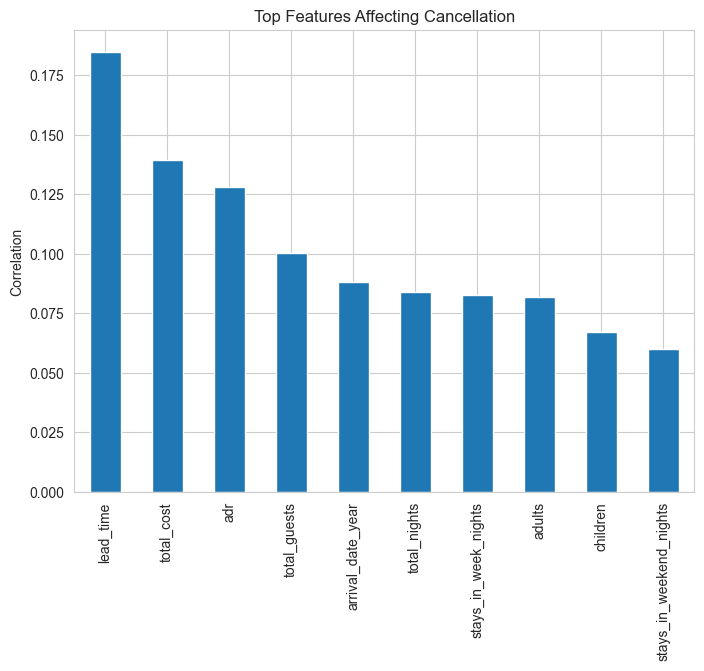

In [50]:
plt.figure(figsize=(8,6))

cancel_corr.drop('is_canceled')\
    .head(10)\
    .plot(kind='bar')

plt.title("Top Features Affecting Cancellation")

plt.ylabel("Correlation")

plt.show()

## MACHINE LEARNING PREPARATION

In [51]:
ml_df = df.copy()

print("ML Dataset Created")

ML Dataset Created


In [52]:
drop_columns = [
    'reservation_status',
    'reservation_status_date'
]

ml_df.drop(
    columns=drop_columns,
    inplace=True
)

print("Columns dropped successfully!")

Columns dropped successfully!


In [53]:
categorical_cols = ml_df.select_dtypes(
    include=['object', 'category']
).columns

print(categorical_cols)

Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type', 'is_family'],
      dtype='str')


In [54]:
le = LabelEncoder()

for col in categorical_cols:
    ml_df[col] = le.fit_transform(
        ml_df[col].astype(str)
    )

print("Categorical columns encoded!")

Categorical columns encoded!


In [55]:
ml_df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,total_guests,total_nights,total_cost,is_family
0,1,0,342,2015,5,27,1,0,0,2,...,0.0,0,2,0.0,0,0,2.0,0,0.0,1
1,1,0,737,2015,5,27,1,0,0,2,...,0.0,0,2,0.0,0,0,2.0,0,0.0,1
2,1,0,7,2015,5,27,1,0,1,1,...,0.0,0,2,75.0,0,0,1.0,1,75.0,1
3,1,0,13,2015,5,27,1,0,1,1,...,0.0,0,2,75.0,0,0,1.0,1,75.0,1
4,1,0,14,2015,5,27,1,0,2,2,...,0.0,0,2,98.0,0,1,2.0,2,196.0,1


In [56]:
X = ml_df.drop(
    'is_canceled',
    axis=1
)

y = ml_df['is_canceled']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (87377, 33)
Target Shape: (87377,)


In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (69901, 33)
Testing Data Shape: (17476, 33)


In [58]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print("Feature Scaling Completed")

Feature Scaling Completed


In [59]:
y.value_counts()

is_canceled
0    63353
1    24024
Name: count, dtype: int64

### Visualize Target Distribution

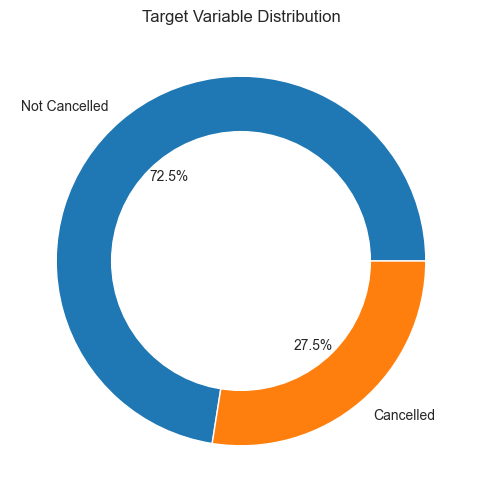

In [60]:
target_counts = pd.Series(y).value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    target_counts,
    labels=['Not Cancelled', 'Cancelled'],
    autopct='%1.1f%%'
)

# lubang tengah
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Target Variable Distribution")

plt.show()

In [61]:
print("""
Data Preparation Completed!

Ready for:
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Model Evaluation
5. Confusion Matrix
6. Classification Report
7. Feature Importance Analysis
""")


Data Preparation Completed!

Ready for:
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Model Evaluation
5. Confusion Matrix
6. Classification Report
7. Feature Importance Analysis



# MACHINE LEARNING MODELS & EVALUATION

### LOGISTIC REGRESSION MODEL

In [62]:
log_model = LogisticRegression(
    max_iter=500,
    random_state=42
)

log_model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression Model Trained!")

Logistic Regression Model Trained!


In [63]:
log_pred = log_model.predict(
    X_test_scaled
)

print("Prediction completed!")

Prediction completed!


In [64]:
log_accuracy = accuracy_score(
    y_test,
    log_pred
)

print("Logistic Regression Accuracy:")
print(round(log_accuracy * 100, 2), "%")

Logistic Regression Accuracy:
77.36 %


### Logistic Regression Confusion Matrix

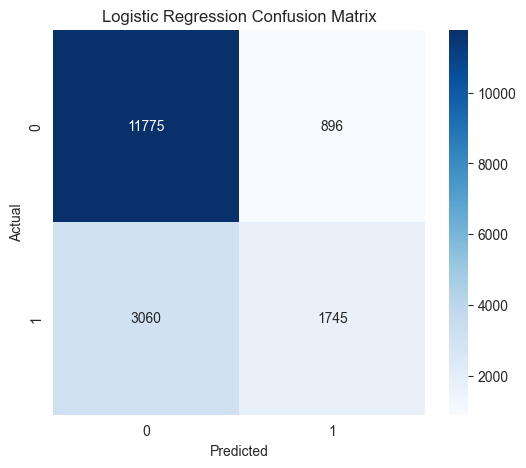

In [65]:
log_cm = confusion_matrix(
    y_test,
    log_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    log_cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [66]:
print("LOGISTIC REGRESSION REPORT")
print()

print(
    classification_report(
        y_test,
        log_pred
    )
)

LOGISTIC REGRESSION REPORT

              precision    recall  f1-score   support

           0       0.79      0.93      0.86     12671
           1       0.66      0.36      0.47      4805

    accuracy                           0.77     17476
   macro avg       0.73      0.65      0.66     17476
weighted avg       0.76      0.77      0.75     17476



## DECISION TREE MODEL

In [67]:
dt_model = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

dt_model.fit(
    X_train,
    y_train
)

print("Decision Tree Model Trained!")

Decision Tree Model Trained!


In [68]:
dt_pred = dt_model.predict(
    X_test
)

In [69]:
dt_accuracy = accuracy_score(
    y_test,
    dt_pred
)

print("Decision Tree Accuracy:")
print(round(dt_accuracy * 100, 2), "%")

Decision Tree Accuracy:
81.75 %


### Decision Tree Confusion Matrix

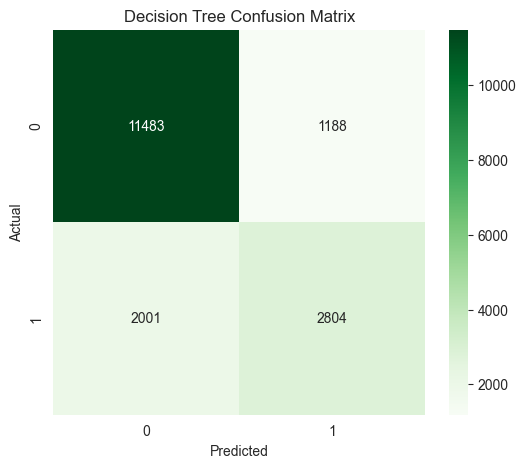

In [70]:
dt_cm = confusion_matrix(
    y_test,
    dt_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    dt_cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [71]:
print("DECISION TREE REPORT")
print()

print(
    classification_report(
        y_test,
        dt_pred
    )
)

DECISION TREE REPORT

              precision    recall  f1-score   support

           0       0.85      0.91      0.88     12671
           1       0.70      0.58      0.64      4805

    accuracy                           0.82     17476
   macro avg       0.78      0.74      0.76     17476
weighted avg       0.81      0.82      0.81     17476



# RANDOM FOREST MODEL

In [72]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest Model Trained!")

Random Forest Model Trained!


In [73]:
rf_pred = rf_model.predict(
    X_test
)

In [74]:
rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print("Random Forest Accuracy:")
print(round(rf_accuracy * 100, 2), "%")

Random Forest Accuracy:
81.84 %


### Random Forest Confusion Matrix

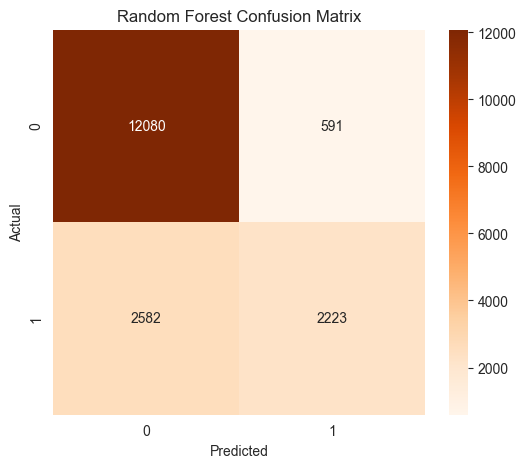

In [75]:
rf_cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [76]:
print("RANDOM FOREST REPORT")
print()

print(
    classification_report(
        y_test,
        rf_pred
    )
)

RANDOM FOREST REPORT

              precision    recall  f1-score   support

           0       0.82      0.95      0.88     12671
           1       0.79      0.46      0.58      4805

    accuracy                           0.82     17476
   macro avg       0.81      0.71      0.73     17476
weighted avg       0.81      0.82      0.80     17476



## MODEL COMPARISON

In [77]:
model_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        log_accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})

model_results

,Model,Accuracy
0,Logistic Regression,0.773632
1,Decision Tree,0.817521
2,Random Forest,0.818437


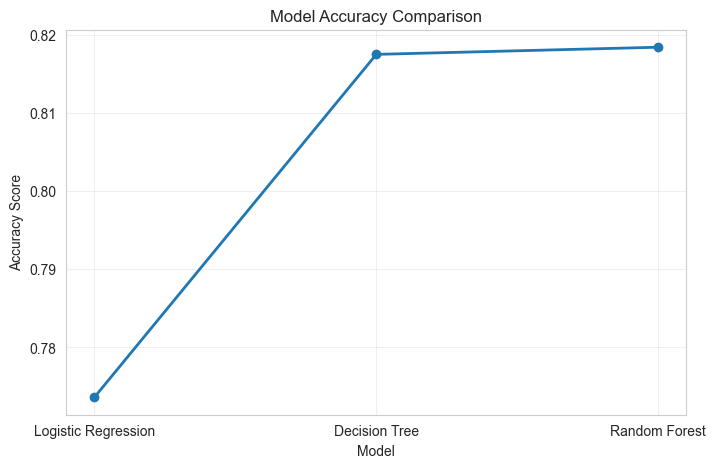

In [78]:
plt.figure(figsize=(8,5))

plt.plot(
    model_results['Model'],
    model_results['Accuracy'],
    marker='o',
    linewidth=2
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy Score")

plt.grid(alpha=0.3)

plt.show()

In [79]:
best_model = model_results.sort_values(
    by='Accuracy',
    ascending=False
)

print("Best Performing Model:")
print(best_model.head(1))

Best Performing Model:
           Model  Accuracy
2  Random Forest  0.818437


## FEATURE IMPORTANCE ANALYSIS

In [80]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
1,lead_time,0.137740
13,market_segment,0.125456
12,country,0.111512
28,total_of_special_requests,0.104795
27,required_car_parking_spaces,0.079062
22,agent,0.078059
21,deposit_type,0.052118
16,previous_cancellations,0.042695
26,adr,0.033278
25,customer_type,0.031568


### Top 15 Important Features

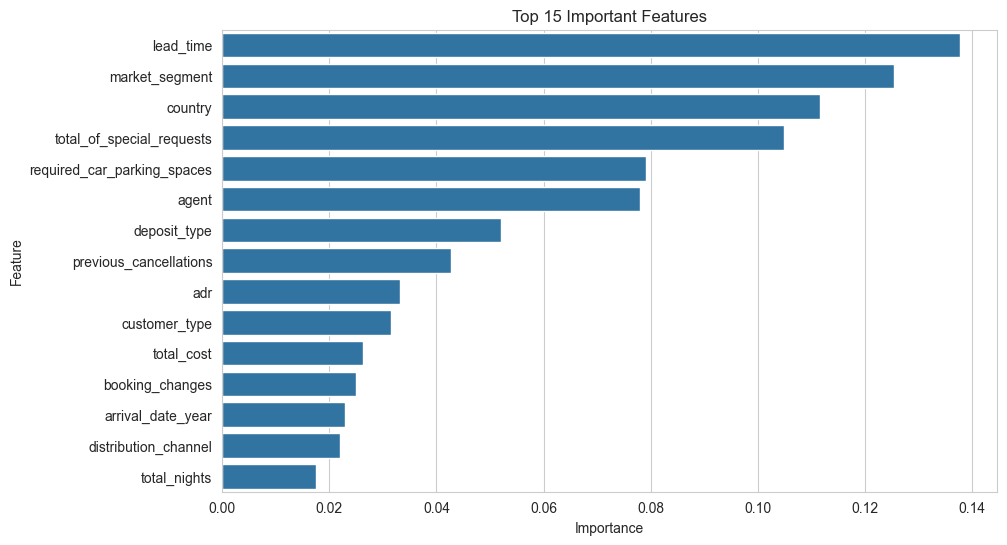

In [81]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features
)

plt.title("Top 15 Important Features")

plt.show()

# FINAL CONCLUSION & ACTIONABLE INSIGHTS

In [82]:
print("""
FINAL CONCLUSION

1. Booking cancellations are significant and impact hotel revenue.

2. Lead time strongly affects cancellation:
   customers booking earlier tend to cancel more.

3. Deposit type influences cancellation:
   no-deposit bookings are more likely to cancel.

4. Hotel demand changes seasonally:
   certain months generate higher bookings.

5. Market segment analysis identifies
   high-value customers.

6. Random Forest typically performs best
   due to its ensemble learning capability.

ACTIONABLE INSIGHTS

1. Encourage deposits to reduce cancellations.

2. Provide discounts for confirmed bookings.

3. Improve marketing during low-demand months.

4. Target high-performing market segments.

5. Focus retention strategies on repeat customers.
""")


FINAL CONCLUSION

1. Booking cancellations are significant and impact hotel revenue.

2. Lead time strongly affects cancellation:
   customers booking earlier tend to cancel more.

3. Deposit type influences cancellation:
   no-deposit bookings are more likely to cancel.

4. Hotel demand changes seasonally:
   certain months generate higher bookings.

5. Market segment analysis identifies
   high-value customers.

6. Random Forest typically performs best
   due to its ensemble learning capability.

ACTIONABLE INSIGHTS

1. Encourage deposits to reduce cancellations.

2. Provide discounts for confirmed bookings.

3. Improve marketing during low-demand months.

4. Target high-performing market segments.

5. Focus retention strategies on repeat customers.



In [83]:
ml_df.to_csv(
    "hotel_booking_final_processed.csv",
    index=False
)

print("Final processed dataset saved!")

Final processed dataset saved!


In [84]:
print("""
HOTEL BOOKING DEMAND ANALYSIS
PROJECT COMPLETED SUCCESSFULLY
""")


HOTEL BOOKING DEMAND ANALYSIS
PROJECT COMPLETED SUCCESSFULLY

